# 🏏 IPL Complete Analysis — Indian Premier League Data Analysis

---

### 📌 Objective
Perform a complete Exploratory Data Analysis on IPL match data to uncover insights about team performances, toss impact, player dominance, venue statistics and title winners across all IPL seasons from 2008 to 2026.

### 📂 Dataset
- **File:** ipl.csv
- **Rows:** 1,243 matches
- **Seasons Covered:** 2008 – 2026 (Complete IPL History)
- **Content:** Match-level data including teams, toss, venue, result, player of the match and more

### 🛠️ Tools Used
- **NumPy** — Numerical operations and conditional column creation
- **Pandas** — Data loading, cleaning, filtering and aggregation
- **Matplotlib** — Core visualizations
- **Seaborn** — Statistical visualizations

### 📊 Analyses Performed
1. Most Successful Teams by Total Wins
2. IPL Season Growth — Matches Per Season
3. Toss Decision Distribution + Trend Over Seasons
4. Toss Winner vs Match Winner
5. Top 10 Player of the Match Winners
6. Most Matches Hosted by Venues
7. Biggest Wins by Runs
8. Teams with Most 10-Wicket Wins
9. Team Win Percentage
10. IPL Title Winners
11. Final Dashboard

---

## 📦 Importing Libraries

In [1]:
# Importing all required libraries for data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 📥 Loading the Dataset

In [2]:
# Loading the IPL dataset into df2 as original
# Working on df — a copy of original so raw data always stays safe
df2 = pd.read_csv('ipl.csv')
df = df2.copy()

## 🔍 Data Exploration

In [3]:
# Exploring dataset — shape, column names, data types, missing values all in one
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1243 entries, 0 to 1242
Data columns (total 31 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   event_name       1243 non-null   object 
 1   season           1243 non-null   object 
 2   match_number     1169 non-null   float64
 3   date             1243 non-null   object 
 4   city             1243 non-null   object 
 5   venue            1243 non-null   object 
 6   team1            1243 non-null   object 
 7   team2            1243 non-null   object 
 8   toss_winner      1243 non-null   object 
 9   toss_decision    1243 non-null   object 
 10  team1_runs       1243 non-null   int64  
 11  team1_wickets    1243 non-null   int64  
 12  team2_runs       1243 non-null   int64  
 13  team2_wickets    1243 non-null   int64  
 14  winner           1218 non-null   object 
 15  result_type      1243 non-null   object 
 16  win_by_runs      1243 non-null   int64  
 17  win_by_wickets

In [4]:
# Checking missing values in each column
df.isnull().sum()

event_name          0
season              0
match_number       74
date                0
city                0
venue               0
team1               0
team2               0
toss_winner         0
toss_decision       0
team1_runs          0
team1_wickets       0
team2_runs          0
team2_wickets       0
winner             25
result_type         0
win_by_runs         0
win_by_wickets      0
player_of_match     9
match_referee       0
umpire1             0
umpire2             0
tv_umpire           0
reserve_umpire      0
match_type          0
overs_limit         0
balls_per_over      0
gender              0
team_type           0
team1_players       0
team2_players       0
dtype: int64

In [5]:
# Previewing first 5 rows to understand the structure of the dataset
df.head()

,event_name,season,match_number,date,city,venue,team1,team2,toss_winner,toss_decision,...,umpire2,tv_umpire,reserve_umpire,match_type,overs_limit,balls_per_over,gender,team_type,team1_players,team2_players
0,Indian Premier League,2007/08,1.0,4/18/2008,Bangalore,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,...,RE Koertzen,AM Saheba,VN Kulkarni,T20,20,6,male,club,"R Dravid, W Jaffer, V Kohli, JH Kallis, CL Whi...","SC Ganguly, BB McCullum, RT Ponting, DJ Hussey..."
1,Indian Premier League,2007/08,2.0,4/19/2008,Chandigarh,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,...,SL Shastri,RB Tiffin,MSS Ranawat,T20,20,6,male,club,"K Goel, JR Hopes, KC Sangakkara, Yuvraj Singh,...","PA Patel, ML Hayden, MEK Hussey, MS Dhoni, SK ..."
2,Indian Premier League,2007/08,3.0,4/19/2008,Delhi,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,...,GA Pratapkumar,IL Howell,Unknown,T20,20,6,male,club,"G Gambhir, V Sehwag, S Dhawan, MK Tiwary, KD K...","T Kohli, YK Pathan, SR Watson, M Kaif, DS Lehm..."
3,Indian Premier League,2007/08,4.0,4/20/2008,Kolkata,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,...,K Hariharan,Asad Rauf,F Gomes,T20,20,6,male,club,"WP Saha, BB McCullum, RT Ponting, SC Ganguly, ...","AC Gilchrist, Y Venugopal Rao, VVS Laxman, A S..."
4,Indian Premier League,2007/08,5.0,4/20/2008,Mumbai,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,...,DJ Harper,AV Jayaprakash,SN Bandekar,T20,20,6,male,club,"L Ronchi, ST Jayasuriya, DJ Thornely, RV Uthap...","S Chanderpaul, R Dravid, LRPL Taylor, JH Kalli..."


## 🧹 Data Cleaning

Steps performed:
- Drop `match_number` column — has 74 missing values and not needed for analysis
- Standardize team names — same franchises had different names across seasons
- Convert `date` column to datetime format
- Extract season year from `date` column

In [6]:
# Dropping match_number column — has 74 missing values and not useful for any analysis
df.drop(columns='match_number', inplace=True)

In [7]:
# Standardizing team names — same franchise had different names across IPL seasons
# Delhi Daredevils was renamed to Delhi Capitals in 2019
# Kings XI Punjab was renamed to Punjab Kings in 2021
# Royal Challengers Bangalore updated to Bengaluru recently
# Rising Pune Supergiant had a typo in some rows
df.replace({
    'Delhi Daredevils'              : 'Delhi Capitals',
    'Kings XI Punjab'               : 'Punjab Kings',
    'Royal Challengers Bangalore'   : 'Royal Challengers Bengaluru',
    'Rising Pune Supergiant'        : 'Rising Pune Supergiants'
}, inplace=True)

In [8]:
# Converting date column from string to datetime format
# Required before extracting year from it
df['date'] = pd.to_datetime(df['date'])

In [9]:
# Extracting year from date column and storing in season column
# More accurate than string slicing — handles all season name formats correctly
df['season'] = df['date'].dt.year

---
## 📊 Analysis 1 — Most Successful Teams by Total Wins

**Question:** Which IPL teams have won the most matches across all seasons?

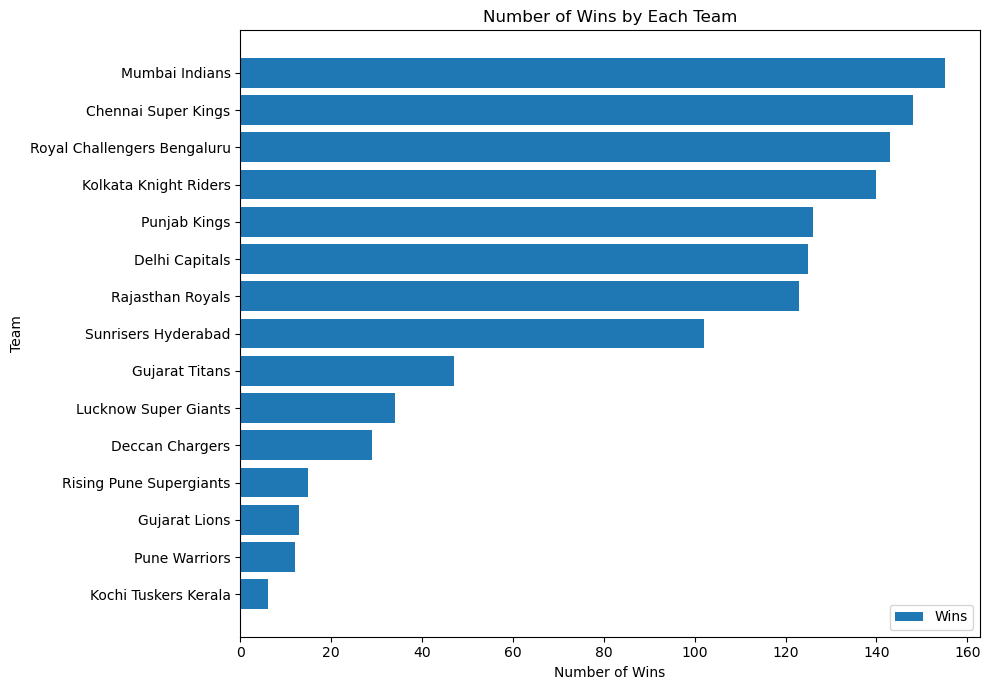

In [10]:
plt.figure(figsize=(10,7))

# Counting total wins per team and sorting from lowest to highest
# sort_values() ensures highest bar appears at top of horizontal chart
winner = df['winner'].value_counts().sort_values()

# Horizontal bar chart — better for long team names on y-axis
plt.barh(winner.index, winner.values, label='Wins')
plt.title('Number of Wins by Each Team')
plt.xlabel('Number of Wins')
plt.ylabel('Team')
plt.legend()
plt.tight_layout()
plt.show()

## 📊 Analysis 2 — IPL Season Growth

**Question:** How has the number of matches grown season by season over IPL history?

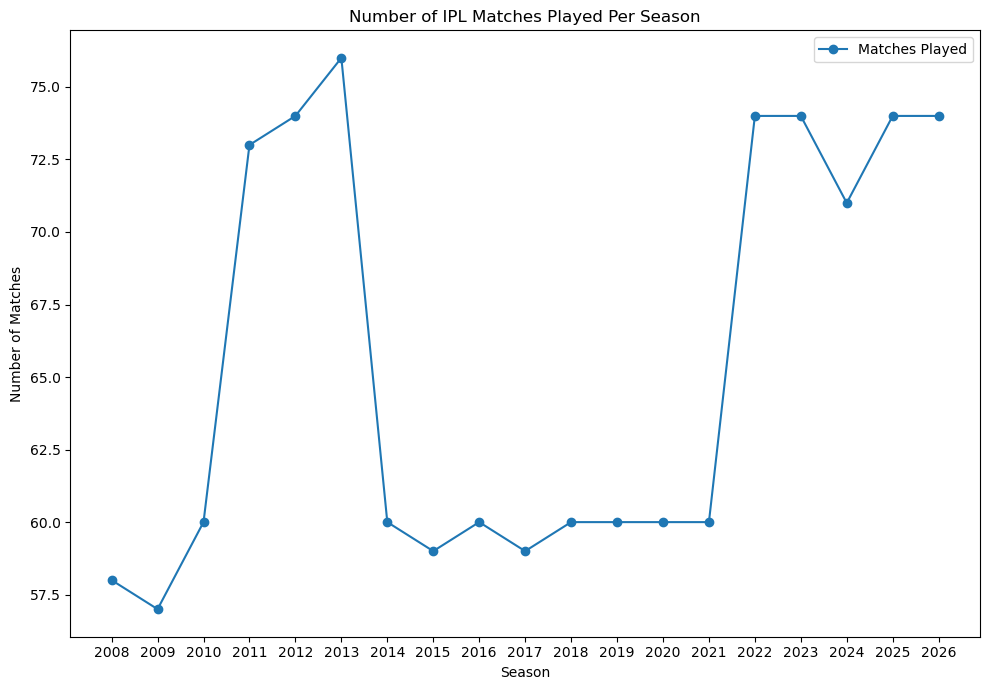

In [11]:
plt.figure(figsize=(10,7))

# Counting matches per season — sort_index() orders by year chronologically
matches = df['season'].value_counts().sort_index()

# Line plot with markers — each point represents one IPL season
plt.plot(matches.index, matches.values, marker='o', label='Matches Played')
plt.title('Number of IPL Matches Played Per Season')
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.legend()

# Displaying every season year on x-axis — no gaps between years
plt.xticks(matches.index)
plt.tight_layout()
plt.show()

## 📊 Analysis 3 — Toss Decision Distribution + Trend Over Seasons

**Question:** Do captains prefer batting or fielding after winning the toss — and has this changed over IPL history?

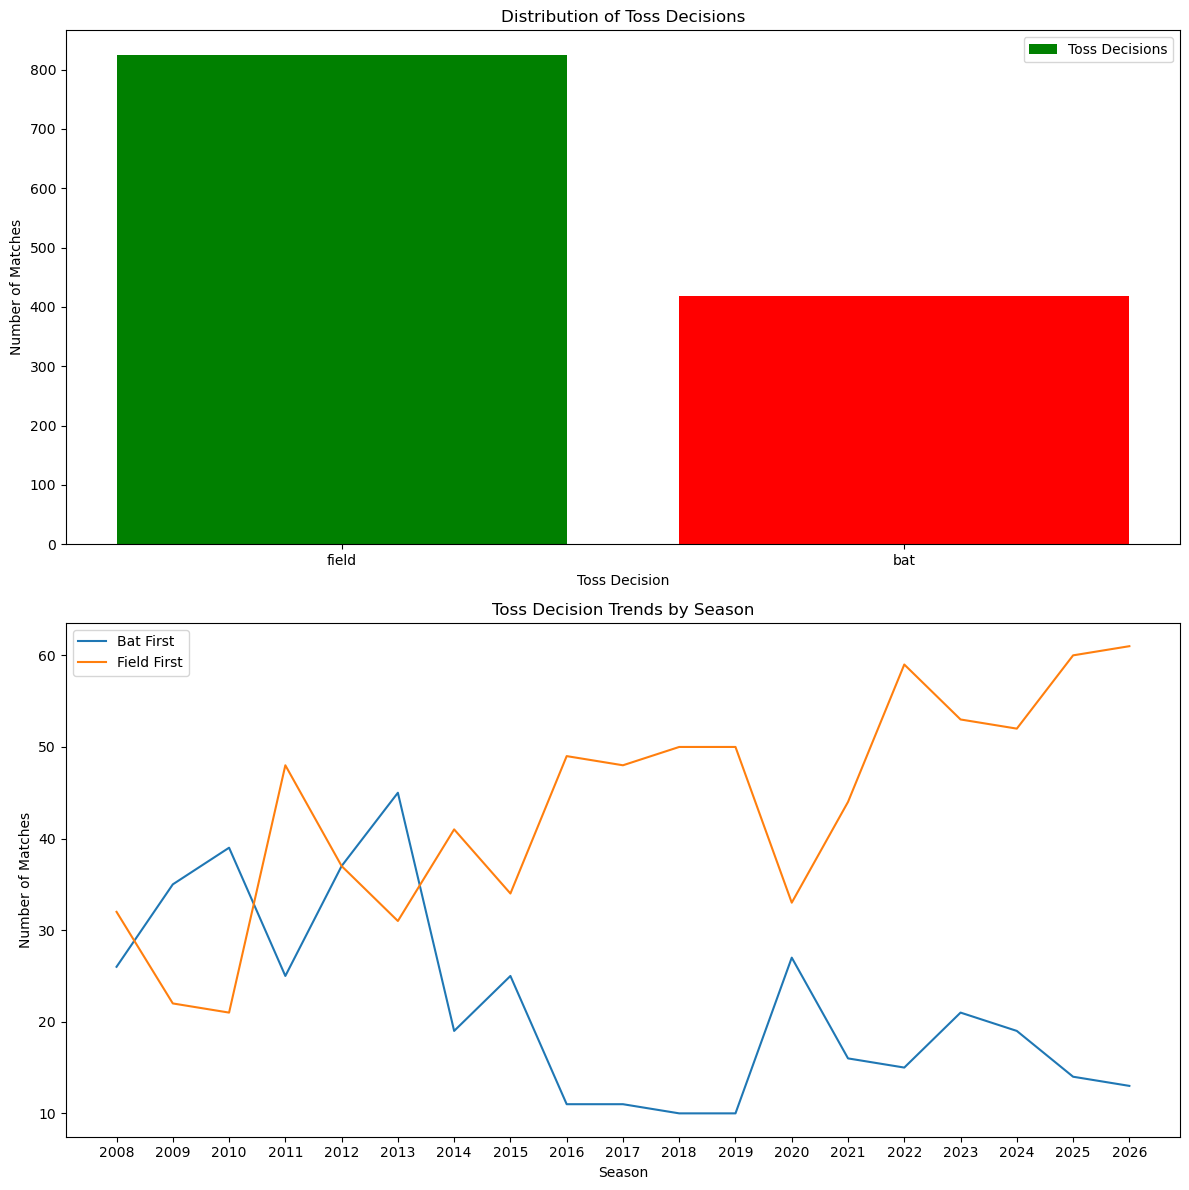

In [12]:
# Overall toss decision count across all seasons
toss_counts = df['toss_decision'].value_counts()

# 2 subplots stacked vertically — top for overall count, bottom for season-wise trend
fig, ax = plt.subplots(2, 1, figsize=(12, 12))

# TOP CHART — Overall count of bat vs field decisions across entire IPL history
ax[0].bar(toss_counts.index, toss_counts.values, color=['green', 'red'], label='Toss Decisions')
ax[0].set_title('Distribution of Toss Decisions')
ax[0].set_xlabel('Toss Decision')
ax[0].set_ylabel('Number of Matches')
ax[0].legend()

# Grouping by season + toss_decision simultaneously — returns a MultiIndex Series
# Index levels: season (outer) and toss_decision (inner)
filtered = df.groupby(['season'])['toss_decision'].value_counts()

# Slicing MultiIndex Series using loc — extracts bat and field as separate clean series
# [:, 'bat'] means: all seasons, only bat decisions
bat = filtered.loc[:, 'bat']
field = filtered.loc[:, 'field']

# BOTTOM CHART — Season-wise trend showing how bat vs field preference changed over time
sns.lineplot(x=bat.index, y=bat.values, ax=ax[1], label='Bat First')
sns.lineplot(x=field.index, y=field.values, ax=ax[1], label='Field First')
ax[1].set_title('Toss Decision Trends by Season')
ax[1].set_xlabel('Season')
ax[1].set_ylabel('Number of Matches')

# Displaying every season year on x-axis
ax[1].set_xticks(bat.index)
ax[1].legend()

fig.tight_layout()
plt.show()

## 📊 Analysis 4 — Toss Winner vs Match Winner

**Question:** Does winning the toss actually help you win the match?

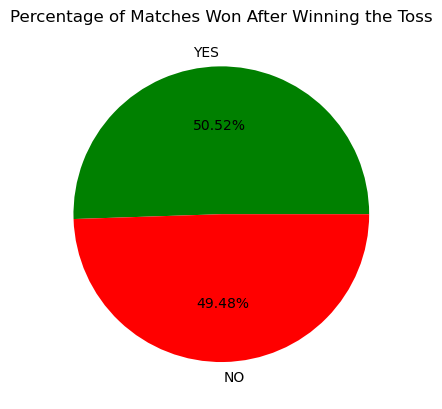

In [13]:
# Creating a new column using np.where — compares toss_winner and winner columns
# YES = toss winner also won the match, NO = toss winner lost the match
df['toss_match_winner'] = np.where(df['toss_winner'] == df['winner'], 'YES', 'NO')

# Counting how many times toss winner won vs lost
winner = df['toss_match_winner'].value_counts()

# Pie chart — ideal for showing percentage split between two outcomes
plt.pie(winner.values, labels=winner.index, colors=['green', 'red'], autopct='%1.2f%%')
plt.title('Percentage of Matches Won After Winning the Toss')
plt.show()

## 📊 Analysis 5 — Top 10 Player of the Match Winners

**Question:** Which players have dominated the Player of the Match award across IPL history?

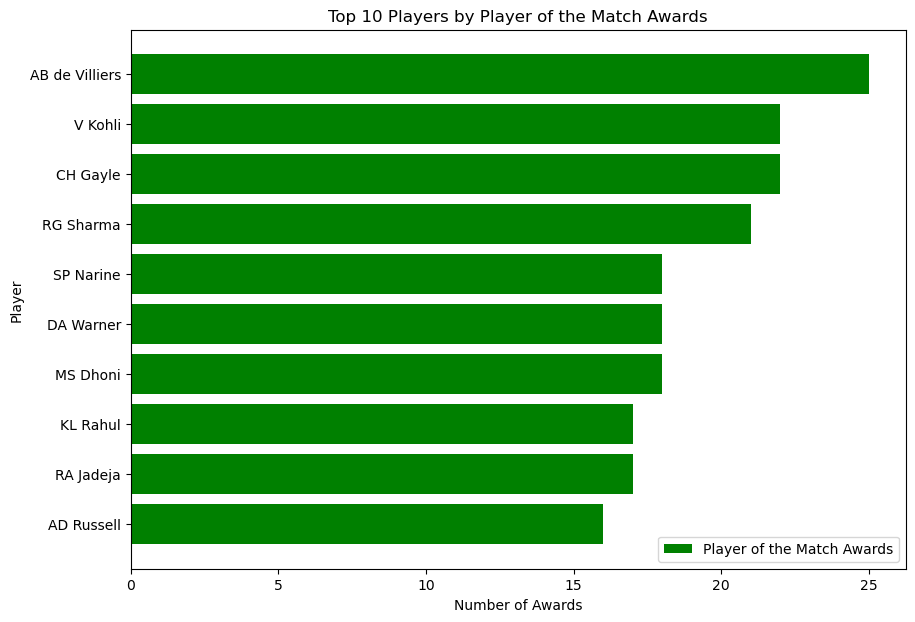

In [14]:
plt.figure(figsize=(10,7))

# Counting POTM awards per player — sort_values() first sorts all players by count
# tail(10) then takes the actual top 10 — more logically correct than head() after sort
POTM = df['player_of_match'].value_counts().sort_values().tail(10)

# Horizontal bar — player names are long, horizontal fits better on y-axis
plt.barh(POTM.index, POTM.values, color='green', label='Player of the Match Awards')
plt.title('Top 10 Players by Player of the Match Awards')
plt.xlabel('Number of Awards')
plt.ylabel('Player')
plt.legend()
plt.show()

## 📊 Analysis 6 — Most Matches Hosted by Venues

**Question:** Which stadiums have hosted the most IPL cricket?

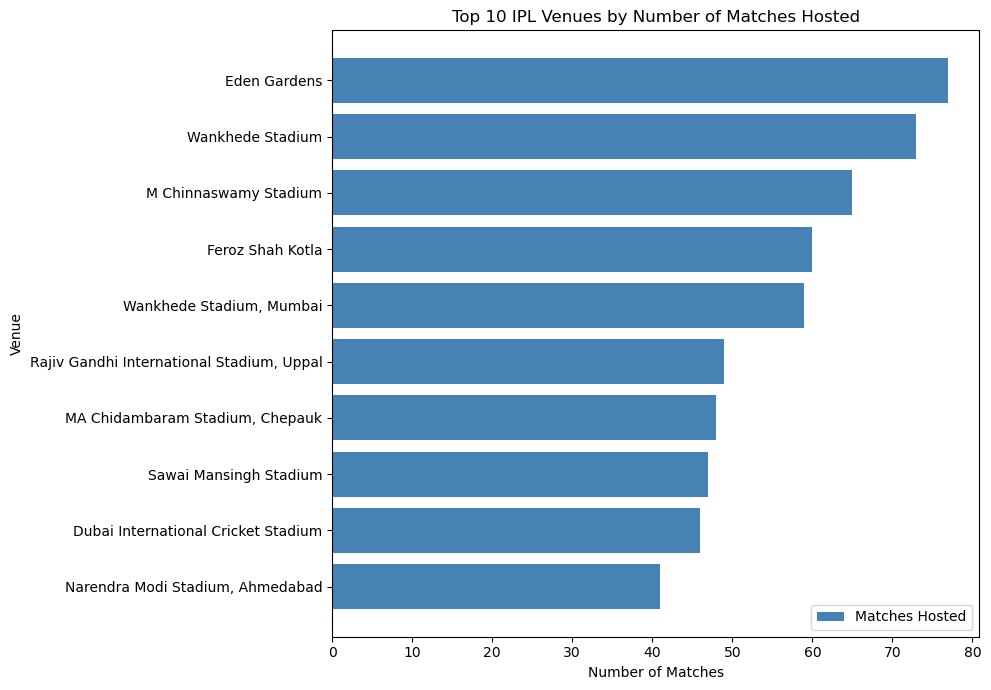

In [15]:
plt.figure(figsize=(10,7))

# Counting matches per venue — sort_values() first, tail(10) takes actual top 10
# More logical than head(10) then sort — ensures correct top 10 selection
venue = df['venue'].value_counts().sort_values().tail(10)

# Horizontal bar — venue names are very long, horizontal layout is essential
plt.barh(venue.index, venue.values, color='steelblue', label='Matches Hosted')
plt.title('Top 10 IPL Venues by Number of Matches Hosted')
plt.xlabel('Number of Matches')
plt.ylabel('Venue')
plt.legend()
plt.tight_layout()
plt.show()

## 📊 Analysis 7 — Biggest Wins by Runs

**Question:** Which matches had the most dominant run victories in IPL history?

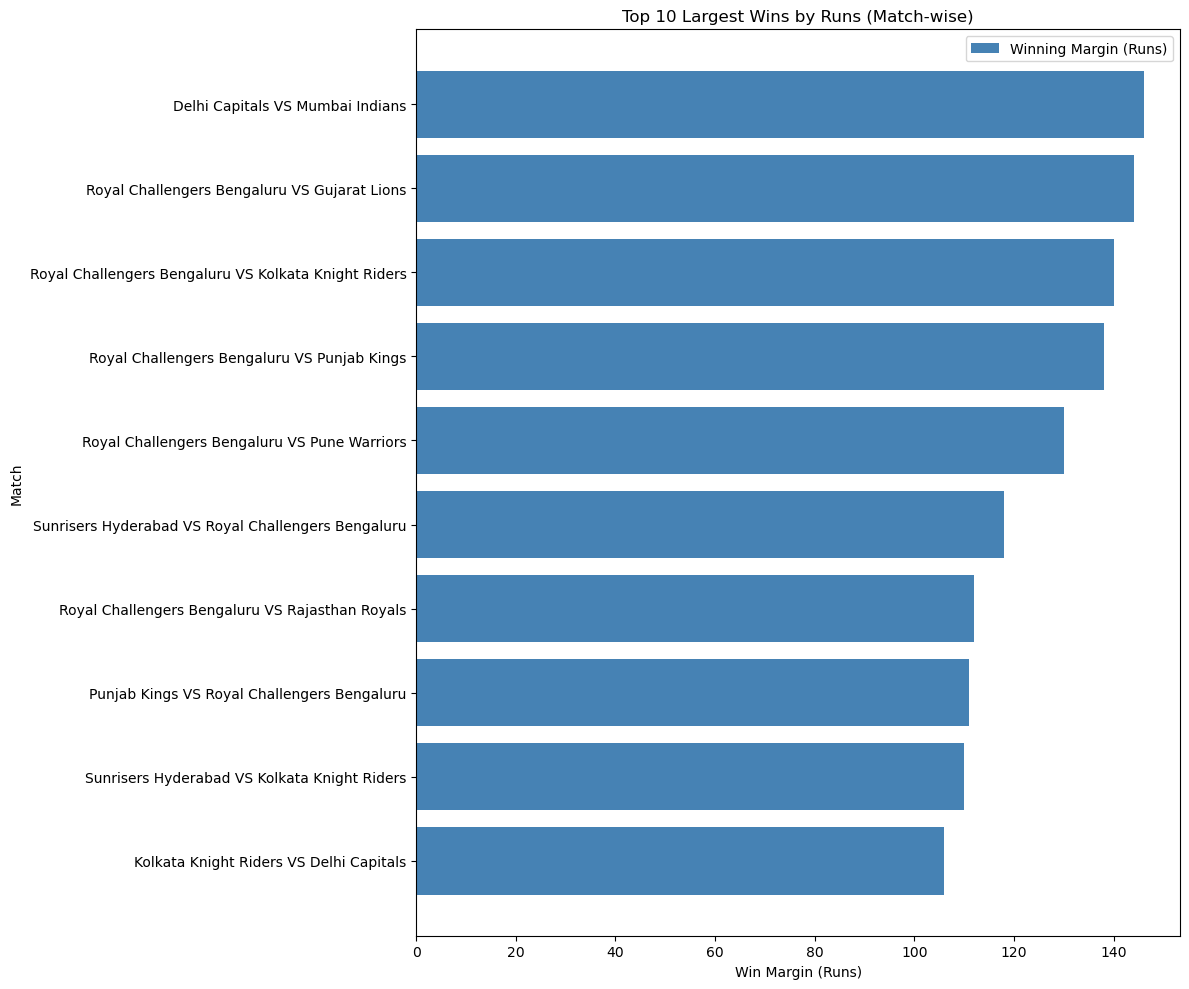

In [16]:
plt.figure(figsize=(12, 10))

# Filtering only matches won by runs — win_by_runs is 0 for all wicket-based wins
filtered = df.loc[df['win_by_runs'] != 0]

# Chaining sort_values() and tail(10) — cleaner than sorting with inplace then slicing
# Gives top 10 matches with highest run margins in one line
data = filtered.sort_values('win_by_runs').tail(10)

# Combining both team names into one label — gives full match context on y-axis
teams = data['team1'] + ' VS ' + data['team2']

plt.barh(teams, data['win_by_runs'], color='steelblue', label='Winning Margin (Runs)')
plt.title('Top 10 Largest Wins by Runs (Match-wise)')
plt.xlabel('Win Margin (Runs)')
plt.ylabel('Match')
plt.legend()
plt.tight_layout()
plt.show()

## 📊 Analysis 8 — Teams with Most 10-Wicket Wins

**Question:** Which teams are most dominant — winning matches by the maximum margin of 10 wickets?

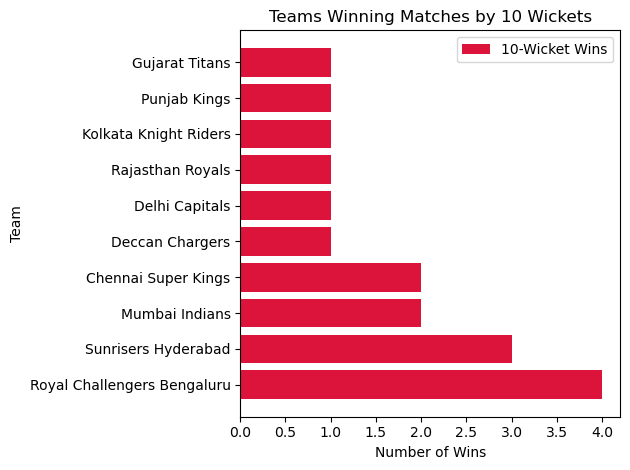

In [17]:
# Filtering matches won by exactly 10 wickets — the maximum possible wicket margin
# No .copy() needed — we are only reading, not modifying this filtered result
filtered = df.loc[df['win_by_wickets'] == 10]

# Counting how many 10-wicket wins each team has achieved across all seasons
winner = filtered['winner'].value_counts()

plt.barh(winner.index, winner.values, color='crimson', label='10-Wicket Wins')
plt.title('Teams Winning Matches by 10 Wickets')
plt.xlabel('Number of Wins')
plt.ylabel('Team')
plt.legend()
plt.tight_layout()
plt.show()

## 📊 Analysis 9 — Team Win Percentage

**Question:** Which teams are most consistently dominant — regardless of how many seasons they played?

> Win percentage is more fair than raw win count since some teams played more seasons than others.

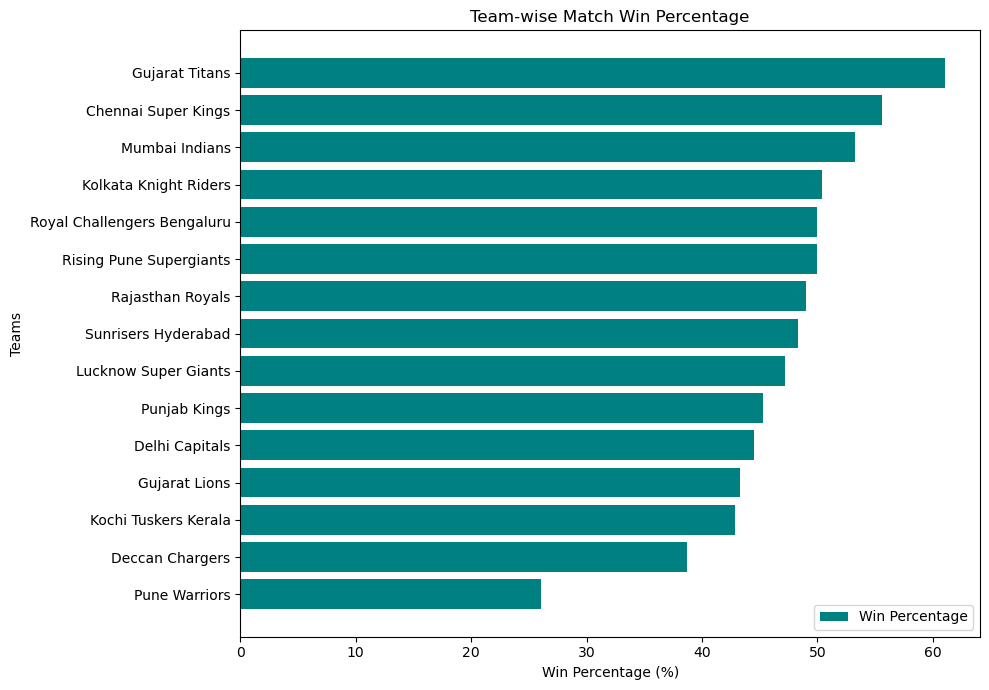

In [18]:
plt.figure(figsize=(10, 7))

# Counting total wins per team — sort_index() alphabetically aligns teams for correct division
winner = df['winner'].value_counts().sort_index()

# Teams appear in both team1 and team2 columns across different matches
# Adding both counts gives accurate total matches played per team
team1 = df['team1'].value_counts().sort_index()
team2 = df['team2'].value_counts().sort_index()
teams = team1 + team2

# Win % = (total wins / total matches) * 100
# sort_index() on all three ensures correct team alignment before division
percentage = ((winner / teams) * 100).sort_values()

plt.barh(percentage.index, percentage.values, color='teal', label='Win Percentage')
plt.title('Team-wise Match Win Percentage')
plt.xlabel('Win Percentage (%)')
plt.ylabel('Teams')
plt.legend()
plt.tight_layout()
plt.show()

## 📊 Analysis 10 — IPL Title Winners

**Question:** Which teams have won the IPL trophy and how many times?

> The last match of each season is the IPL Final — its winner is the title winner of that season.

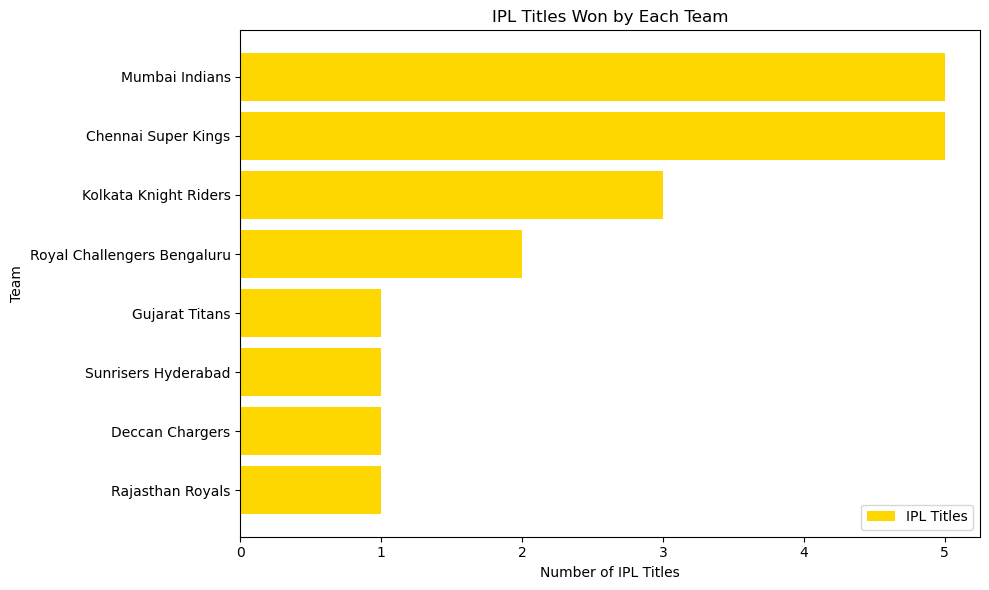

In [19]:
plt.figure(figsize=(10, 6))

# groupby('season').tail(1) gets the very last row of each season group
# Last match of every season = IPL Final — winner of that match = Title Winner
filtered = df.groupby('season').tail(1)

# Counting title wins per team and sorting for better visual
winner = filtered['winner'].value_counts().sort_values()

plt.barh(winner.index, winner.values, color='gold', label='IPL Titles')
plt.title('IPL Titles Won by Each Team')
plt.xlabel('Number of IPL Titles')
plt.ylabel('Team')
plt.legend()
plt.tight_layout()
plt.show()

---
## 📊 Final Dashboard — IPL Analysis Summary

Combining the 6 most insightful analyses into one complete dashboard.

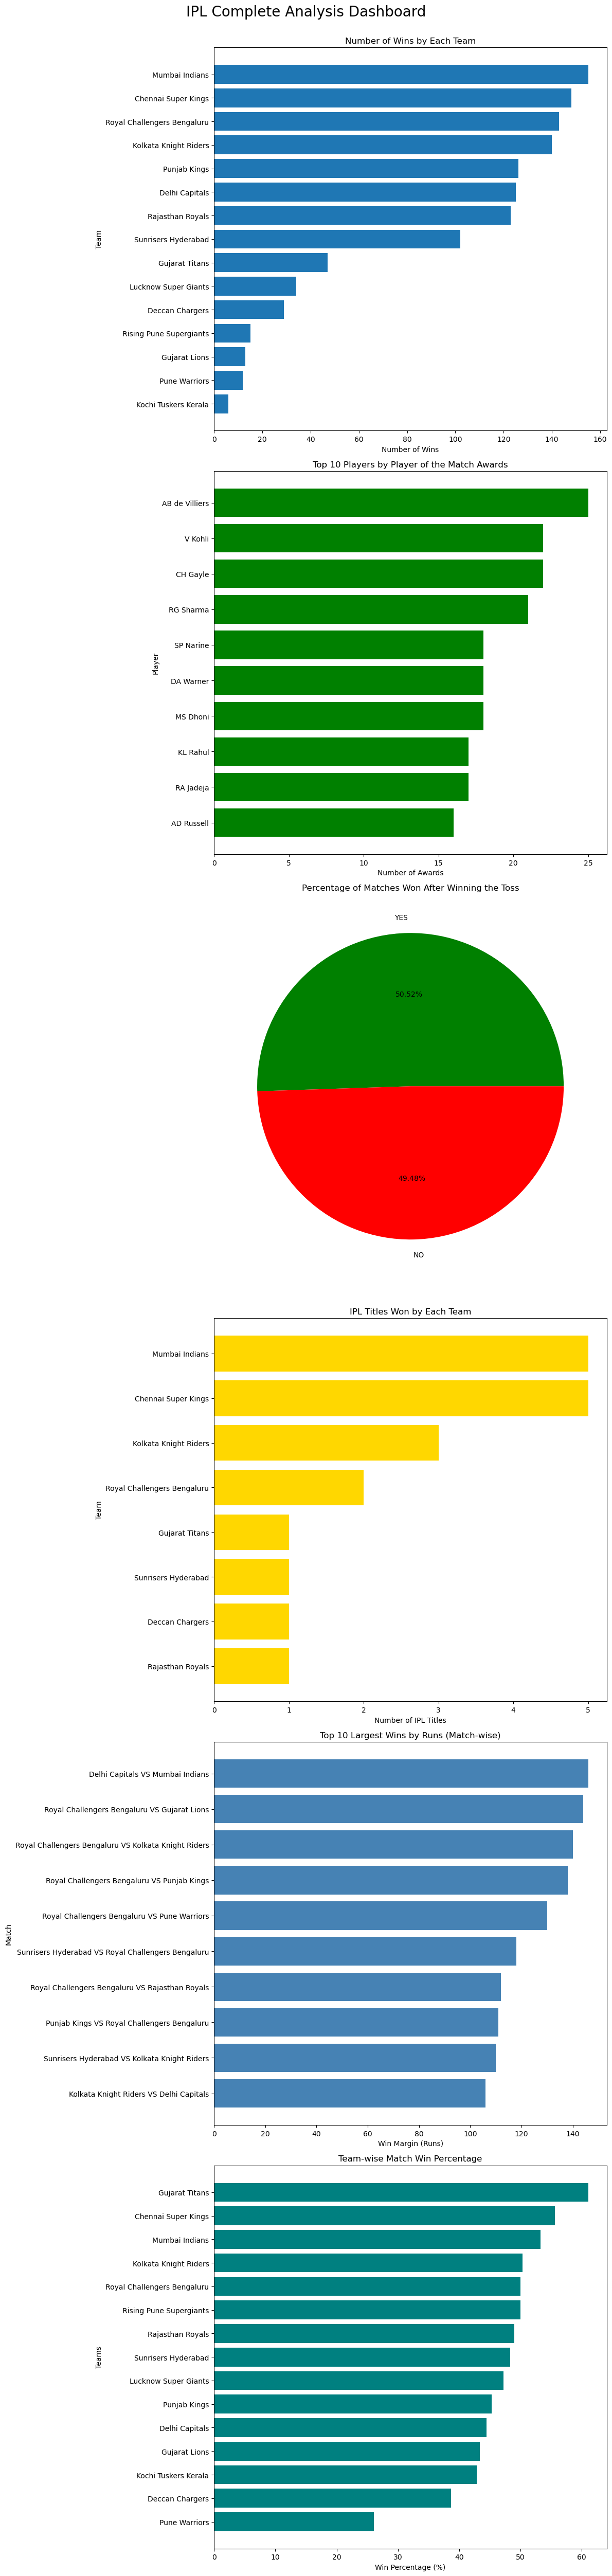

In [20]:
# Creating a 1D grid of 6 subplots stacked vertically
# figsize=(12,50) gives enough height for all 6 horizontal bar charts to be readable
fig, ax = plt.subplots(6, figsize=(12, 50))

# --- SUBPLOT 1 --- Most Successful Teams by Total Wins
winner = df['winner'].value_counts().sort_values()
ax[0].barh(winner.index, winner.values, label='Wins')
ax[0].set_title('Number of Wins by Each Team')
ax[0].set_xlabel('Number of Wins')
ax[0].set_ylabel('Team')

# --- SUBPLOT 2 --- Top 10 Player of the Match Winners
# sort_values().tail(10) — sorts all players first then takes actual top 10
POTM = df['player_of_match'].value_counts().sort_values().tail(10)
ax[1].barh(POTM.index, POTM.values, color='green', label='Player of the Match Awards')
ax[1].set_title('Top 10 Players by Player of the Match Awards')
ax[1].set_xlabel('Number of Awards')
ax[1].set_ylabel('Player')

# --- SUBPLOT 3 --- Toss Winner vs Match Winner
# np.where compares toss_winner and winner — YES if same, NO if different
df['toss_match_winner'] = np.where(df['toss_winner'] == df['winner'], 'YES', 'NO')
winner = df['toss_match_winner'].value_counts()
ax[2].pie(winner.values, labels=winner.index, colors=['green', 'red'], autopct='%1.2f%%')
ax[2].set_title('Percentage of Matches Won After Winning the Toss')

# --- SUBPLOT 4 --- IPL Title Winners
# groupby('season').tail(1) extracts last match of each season = IPL Final
filtered = df.groupby('season').tail(1)
winner = filtered['winner'].value_counts().sort_values()
ax[3].barh(winner.index, winner.values, color='gold', label='IPL Titles')
ax[3].set_title('IPL Titles Won by Each Team')
ax[3].set_xlabel('Number of IPL Titles')
ax[3].set_ylabel('Team')

# --- SUBPLOT 5 --- Biggest Wins by Runs
# Filtering win_by_runs != 0 removes all wicket-based wins
# Chaining sort_values().tail(10) is cleaner than inplace sorting
filtered = df.loc[df['win_by_runs'] != 0]
data = filtered.sort_values('win_by_runs').tail(10)
teams = data['team1'] + ' VS ' + data['team2']
ax[4].barh(teams, data['win_by_runs'], color='steelblue', label='Winning Margin (Runs)')
ax[4].set_title('Top 10 Largest Wins by Runs (Match-wise)')
ax[4].set_xlabel('Win Margin (Runs)')
ax[4].set_ylabel('Match')

# --- SUBPLOT 6 --- Team Win Percentage
# Adding team1 + team2 counts gives total matches played per team
# sort_index() on all three ensures correct alignment before division
winner = df['winner'].value_counts().sort_index()
team1 = df['team1'].value_counts().sort_index()
team2 = df['team2'].value_counts().sort_index()
teams = team1 + team2
percentage = ((winner / teams) * 100).sort_values()
ax[5].barh(percentage.index, percentage.values, color='teal', label='Win Percentage')
ax[5].set_title('Team-wise Match Win Percentage')
ax[5].set_xlabel('Win Percentage (%)')
ax[5].set_ylabel('Teams')

fig.suptitle('IPL Complete Analysis Dashboard', fontsize=20, y=1.001)
fig.tight_layout()
plt.show()

---
## 🔍 Dataset Preview

In [21]:
# Displaying first 5 rows of the cleaned dataset
df.head()

,event_name,season,date,city,venue,team1,team2,toss_winner,toss_decision,team1_runs,...,tv_umpire,reserve_umpire,match_type,overs_limit,balls_per_over,gender,team_type,team1_players,team2_players,toss_match_winner
0,Indian Premier League,2008,2008-04-18,Bangalore,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,82,...,AM Saheba,VN Kulkarni,T20,20,6,male,club,"R Dravid, W Jaffer, V Kohli, JH Kallis, CL Whi...","SC Ganguly, BB McCullum, RT Ponting, DJ Hussey...",NO
1,Indian Premier League,2008,2008-04-19,Chandigarh,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,207,...,RB Tiffin,MSS Ranawat,T20,20,6,male,club,"K Goel, JR Hopes, KC Sangakkara, Yuvraj Singh,...","PA Patel, ML Hayden, MEK Hussey, MS Dhoni, SK ...",YES
2,Indian Premier League,2008,2008-04-19,Delhi,Feroz Shah Kotla,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,132,...,IL Howell,Unknown,T20,20,6,male,club,"G Gambhir, V Sehwag, S Dhawan, MK Tiwary, KD K...","T Kohli, YK Pathan, SR Watson, M Kaif, DS Lehm...",NO
3,Indian Premier League,2008,2008-04-20,Kolkata,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,112,...,Asad Rauf,F Gomes,T20,20,6,male,club,"WP Saha, BB McCullum, RT Ponting, SC Ganguly, ...","AC Gilchrist, Y Venugopal Rao, VVS Laxman, A S...",NO
4,Indian Premier League,2008,2008-04-20,Mumbai,Wankhede Stadium,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,165,...,AV Jayaprakash,SN Bandekar,T20,20,6,male,club,"L Ronchi, ST Jayasuriya, DJ Thornely, RV Uthap...","S Chanderpaul, R Dravid, LRPL Taylor, JH Kalli...",NO
